<a href="https://colab.research.google.com/github/123hawaa/ML-AdaptiveBeamforming-5G-MassiveMIMO/blob/master/KNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**KNN algorithm to detect the optimum user subarray based on user demands**

import libraries

In [ ]:
# Step 1: Install dependencies (if not already in Colab)
!pip install scikit-learn pandas matplotlib seaborn


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import the system model dataset

In [ ]:
# Step 3: Load CSV
df = pd.read_csv('/content/DATA_shuffled.csv')
df = df.sample(frac=1).reset_index(drop=True)
print("✅ Data loaded and shuffled with shape:", df.shape)
df.head()


✅ Data loaded and shuffled with shape: (3024, 11)


,BS,Sector,UserID,AssignedPRBs,Rk_Mbps,MOk,maximum_throughput,TotalPower_W,BSTotalPower_W,Select_Subarrays,SelectedSubarray
0,42,2,1490,7,9,2,1.083022e+06,0.136092,38.093966,2,2.0
1,68,3,2441,8,11,2,1.443988e+06,0.681475,9.105584,2,2.0
2,71,1,2525,11,45,6,1.985532e+06,0.100000,10.442715,5,5.0
3,53,3,1907,13,53,6,2.346510e+06,0.457739,11.783066,7,7.0
4,26,1,906,14,58,6,2.527047e+06,0.100000,7.215531,9,9.0


## data preprocessing


In [ ]:
# Step 4: Identify the label column (some exports use Select_Subarrays instead)

train_df = df.drop(columns=['BS', 'Sector', 'UserID', 'BSTotalPower_W' , 'maximum_throughput','SelectedSubarray','TotalPower_W'])
y = train_df['Select_Subarrays']


print("Predictors:", train_df.columns.tolist())

train_df.head()

Predictors: ['AssignedPRBs', 'Rk_Mbps', 'MOk', 'Select_Subarrays']


,AssignedPRBs,Rk_Mbps,MOk,Select_Subarrays
0,7,9,2,2
1,8,11,2,2
2,11,45,6,5
3,13,53,6,7
4,14,58,6,9


In [ ]:
len(df)

3024

In [ ]:
print(train_df.isna().sum())

AssignedPRBs        0
Rk_Mbps             0
MOk                 0
Select_Subarrays    0
dtype: int64


In [ ]:
print(train_df.dtypes)

AssignedPRBs        int64
Rk_Mbps             int64
MOk                 int64
Select_Subarrays    int64
dtype: object


In [ ]:
print(train_df['Select_Subarrays'].value_counts())

Select_Subarrays
2     835
3     529
4     506
10    237
5     232
8     200
9     155
6     152
7     129
1      49
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Step 5: Split data

X = train_df.drop(columns=['Select_Subarrays'])
y = train_df['Select_Subarrays']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , random_state=42, stratify=y
)

# Step 6: Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

len(X_train_scaled)


2116

In [ ]:
X_test.head()

,AssignedPRBs,Rk_Mbps,MOk
1510,0,41,4
2370,14,57,6
2928,14,58,6
2227,12,17,2
417,7,10,2


In [ ]:
len(y_test)

908

In [ ]:
len(X_test_scaled)

908

## KNN model

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [ ]:
knn.score(X_train_scaled, y_train)

1.0

In [ ]:
y_pred = knn.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.987885462555066

## Visulaizations

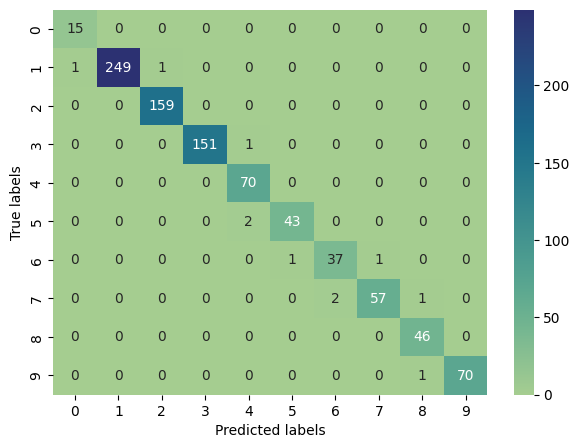

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix


%matplotlib inline
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g', cmap ='crest')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.94      1.00      0.97        15
           2       1.00      0.99      1.00       251
           3       0.99      1.00      1.00       159
           4       1.00      0.99      1.00       152
           5       0.96      1.00      0.98        70
           6       0.98      0.96      0.97        45
           7       0.95      0.95      0.95        39
           8       0.98      0.95      0.97        60
           9       0.96      1.00      0.98        46
          10       1.00      0.99      0.99        71

    accuracy                           0.99       908
   macro avg       0.98      0.98      0.98       908
weighted avg       0.99      0.99      0.99       908



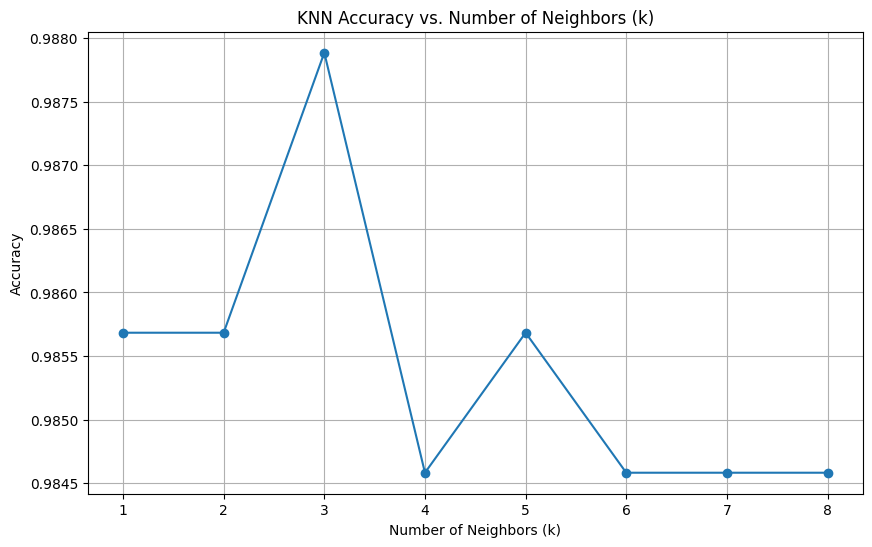

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Define a range of k values to test
k_range = range(1, 9)
accuracies = []

# Train and evaluate KNN for each k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance') # Using weights='distance' as in your previous code
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy)

# Visualize accuracy vs. k
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='-')
plt.title('KNN Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

/tmp/ipython-input-2122997306.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recall_series.index, y=recall_series.values, palette='viridis')


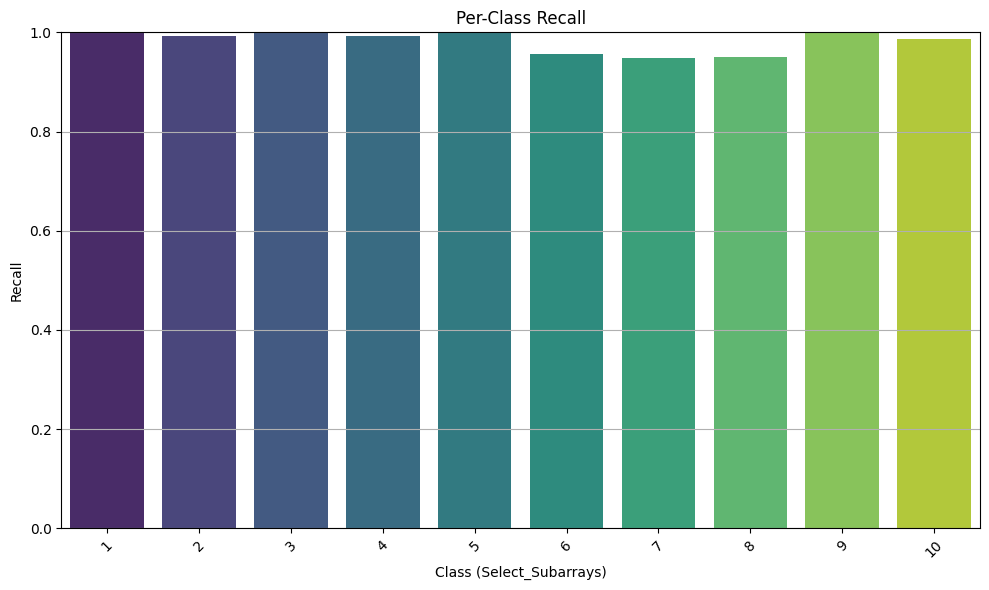

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get the classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Extract recall values for each class
recall_by_class = {}
for label, metrics in report.items():
    # Exclude 'accuracy', 'macro avg', 'weighted avg'
    if label not in ['accuracy', 'macro avg', 'weighted avg']:
        recall_by_class[label] = metrics['recall']

# Convert to pandas Series for easy plotting
recall_series = pd.Series(recall_by_class)

# Create a bar plot of per-class recall
plt.figure(figsize=(10, 6))
sns.barplot(x=recall_series.index, y=recall_series.values, palette='viridis')
plt.ylim(0, 1.0) # Recall is between 0 and 1
plt.title('Per-Class Recall')
plt.xlabel('Class (Select_Subarrays)')
plt.ylabel('Recall')
plt.xticks(rotation=45) # Rotate labels if they overlap
plt.grid(axis='y')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

## Test our model with this use cases

In [ ]:
# Example of using the trained model for prediction (a direct use case)

# Create some sample new data with the same features as your training data
# These values should be representative of the data your model will encounter in a real use case
new_data = pd.DataFrame({
    'AssignedPRBs': [10, 15, 8],
    'Rk_Mbps': [30, 45, 20],
    'MOk': [4, 6, 2]
})

# Scale the new data using the same scaler fitted on the training data
new_data_scaled = scaler.transform(new_data)

# Make predictions using the trained KNN model
predicted_subarrays = knn.predict(new_data_scaled)

# Print the predictions
print("Sample new data:")
display(new_data)
print("\nPredicted Select_Subarrays for the new data:")
print(predicted_subarrays)

Sample new data:


,AssignedPRBs,Rk_Mbps,MOk
0,10,30,4
1,15,45,6
2,8,20,2



Predicted Select_Subarrays for the new data:
[3 8 2]
